In [6]:
# Cek versi Python yang digunakan Google Colab
import sys
print('Versi Python:', sys.version)

# Import library dasar untuk pengolahan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Seluruh library berhasil diimpor.')

Versi Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Seluruh library berhasil diimpor.


In [7]:
!python --version

Python 3.13.15


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# Informasi struktur dataset: jumlah baris, kolom, dan tipe data
df.info()

# Statistik deskriptif dasar untuk kolom numerik
df.describe()

# Menampilkan tipe data tiap kolom
print(df.dtypes)

# Jumlah baris dan kolom
print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin         

In [12]:
import seaborn as sns

df = sns.load_dataset("titanic")

# DATA: nilai mentah pada kolom 'survived' dan 'sex'
print(df[['survived', 'sex', 'age', 'fare']].head())

# INFORMASI: mengolah data menjadi ringkasan bermakna
info_gender = df.groupby('sex')['survived'].mean() * 100
print('Persentase korban selamat berdasarkan jenis kelamin:')
print(info_gender)

# INFORMASI: rata-rata umur penumpang
print("Rata-rata umur penumpang:", df["age"].mean())

# INFORMASI: jumlah penumpang selamat
print("Jumlah penumpang selamat:", df[["survived"]].sum())


   survived     sex   age     fare
0         0    male  22.0   7.2500
1         1  female  38.0  71.2833
2         1  female  26.0   7.9250
3         1  female  35.0  53.1000
4         0    male  35.0   8.0500
Persentase korban selamat berdasarkan jenis kelamin:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64
Rata-rata umur penumpang: 29.69911764705882
Jumlah penumpang selamat: survived    342
dtype: int64


In [13]:
# PENGETAHUAN: pola yang berulang dari beberapa variabel
knowledge = df.groupby(['sex', 'pclass'])['survived'].mean() * 100
print('Persentase selamat berdasarkan jenis kelamin dan kelas kabin:')
print(knowledge)

# INSIGHT: kesimpulan actionable dari pola yang ditemukan
print('\nINSIGHT:')
print('Penumpang perempuan di kelas 1 memiliki tingkat keselamatan tertinggi,')
print('sementara penumpang laki-laki di kelas 3 memiliki tingkat keselamatan terendah.')
print('Insight ini dapat mendukung kebijakan prioritas evakuasi berbasis data historis.')

Persentase selamat berdasarkan jenis kelamin dan kelas kabin:
sex     pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

INSIGHT:
Penumpang perempuan di kelas 1 memiliki tingkat keselamatan tertinggi,
sementara penumpang laki-laki di kelas 3 memiliki tingkat keselamatan terendah.
Insight ini dapat mendukung kebijakan prioritas evakuasi berbasis data historis.


In [14]:
# Insight sederhana
survival_rate = df["survived"].mean()*100
print(f"Tingkat keselamatan: {survival_rate:.2f}")

if(survival_rate < 50):
  print("Insight: Mayoritas penumpang tidak selamat, perlu investigasi faktor penyebab")

Tingkat keselamatan: 38.38
Insight: Mayoritas penumpang tidak selamat, perlu investigasi faktor penyebab


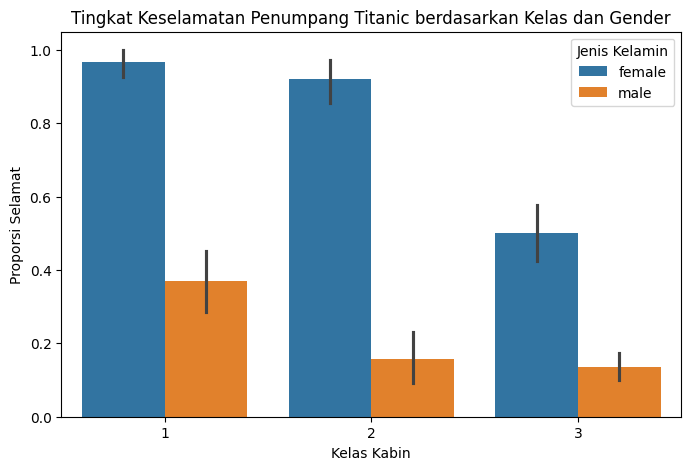

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Tingkat Keselamatan Penumpang Titanic berdasarkan Kelas dan Gender')
plt.xlabel('Kelas Kabin')
plt.ylabel('Proporsi Selamat')
plt.legend(title='Jenis Kelamin')
plt.show()

PRAKTIKUM 2

In [16]:
import pandas as pd

df_source = pd.read_csv('content/train.csv')

# 2. Pengelompokan usia dan analisis (perhatikan kapitalisasi 'Age' dan 'Survived')
df_source['age_group'] = pd.cut(
    df_source['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Anak', 'Remaja', 'Dewasa', 'Lansia'],
)

print(df_source.groupby('age_group', observed=True)['Survived'].mean() * 100)
print(df_source['age_group'].value_counts())

age_group
Anak      57.971014
Remaja    42.857143
Dewasa    38.878843
Lansia    22.727273
Name: Survived, dtype: float64
age_group
Dewasa    553
Remaja     70
Anak       69
Lansia     22
Name: count, dtype: int64


In [17]:
import pandas as pd

# Pembagian kuartil tarif (Fare) dan perhitungan tingkat keselamatan (Survived)
df_source['fare_group'] = pd.qcut(
    df_source['Fare'],
    q=4,
    labels=['Murah', 'Sedang', 'Mahal', 'Sangat Mahal']
)

print(df_source.groupby('fare_group', observed=True)['Survived'].mean() * 100)

fare_group
Murah           19.730942
Sedang          30.357143
Mahal           45.495495
Sangat Mahal    58.108108
Name: Survived, dtype: float64


In [18]:
import pandas as pd

# 1. Perhitungan tingkat keselamatan berdasarkan pelabuhan keberangkatan
print(df_source.groupby('Embarked')['Survived'].mean() * 100)

# 2. Distribusi jumlah penumpang per pelabuhan
print(df_source['Embarked'].value_counts())

# 3. Analisis lanjutan (Crosstab) untuk mengonfirmasi Confounding Variable (Embarked x Pclass)
print(pd.crosstab(df_source['Embarked'], df_source['Pclass'], normalize='index') * 100)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Pclass            1          2          3
Embarked                                 
C         50.595238  10.119048  39.285714
Q          2.597403   3.896104  93.506494
S         19.720497  25.465839  54.813665
